# DocuSketch Indoor Object Detection

### Introduction

In this notebook, I present my solution to **DocuSketch's home assignment** for the **AI/ML Engineer** hiring process.

The task is to **train and evaluate an object detection model** of my choice on the **Indoor Object Detection Dataset** from Tampere University of Technology.

- **Dataset:** https://zenodo.org/record/2654485#.YaYShVPMJhE  
- **Paper:** https://arxiv.org/pdf/1807.03142  

This is a **well-scoped** object detection problem: high-resolution indoor images, a **manageable number of classes**, and enough data to fine-tune a modern detector from **pretrained weights**. It still has real-world wrinkles — especially **strong class imbalance**, **thin val/test support for rare classes**, and some **bounding-box inconsistencies**.

The original paper reports **97.73% mAP** with SSD MobileNet, but that number uses **IoU = 0.5**, so it lines up more with **mAP50** than with the stricter **COCO-style mAP50-95**. I use both **mAP50** and **mAP50-95** here to separate *“did we find the right object?”* from *“how tight is the box?”*

My goal was **not** to chase a leaderboard score. I focused on a **clean, reproducible pipeline** that shows how I tackle a new vision dataset: inspection → distribution analysis → **stratified split** → model choice → training → metrics → **qualitative error review**.

---

### Methodology

The solution follows this workflow:

1. **Dataset inspection and analysis**  
   Inspect structure, annotations, image properties, and class frequencies. Understand **class imbalance** and annotation quality before training.

2. **Model selection**  
   Chose **YOLOv8** (Ultralytics) as the baseline: good **accuracy/speed** trade-off, pretrained weights, simple custom-data training, and solid built-in metrics.

3. **Repository and experiment structure**  
   Built a small **reproducible repo** (not notebook-only code), developed locally, then wired so the **full pipeline runs from this notebook**.

4. **Balanced train/validation/test split**  
   **80/10/10** image-level split with class distributions kept as close as possible. **ILP-based splitting** so rare classes still appear in train, val, and test.

5. **YOLO dataset preparation**  
   Converted XML annotations to YOLO format: one label file per image, boxes as `class_id x_center y_center width height` (normalized).

6. **Baseline training**  
   Trained **YOLOv8** from pretrained weights: first a **minimal config** to validate the pipeline, then the **standard Ultralytics augmentations** for the main run.

7. **Evaluation**  
   Report **mAP50**, **mAP50-95**, precision, recall, and **per-class** metrics on validation/test — read together with **how many instances** each rare class has.

8. **Qualitative analysis**  
   Visual panels of **strong and weak** predictions to spot missed objects, loose boxes, false positives, and **class confusion**.

---
### Setup

To get things started, let's first set up our environment and our paths.

In [2]:
import os
import subprocess
import sys
from pathlib import Path


def _find_repo() -> Path:
    seen: set[Path] = set()
    for root in [Path.cwd().resolve(), *list(Path.cwd().resolve().parents)[:8]]:
        r = root.resolve()
        if r in seen:
            continue
        seen.add(r)
        if (r / "train_and_eval.py").is_file() and (r / "requirements.txt").is_file():
            return r
    raise FileNotFoundError(
        "Project root not found (expected train_and_eval.py and requirements.txt)."
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print("Installing dependencies from requirements.txt ...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-U", "-r", str(REPO / "requirements.txt")],
    check=True,
)

import torch

print(f"REPO:  {REPO}")
print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("GPU:     none (training will be slow on CPU)")

DATA_ROOT = REPO / "data" / "indoor_object_detection_dataset"
YOLO_ROOT = REPO / "prepared_data" / "yolo_indoor_object_detection"

Installing dependencies from requirements.txt ...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


REPO:  /home/francisco/workspace/personal_projects/docusketch_assignment
PyTorch 2.12.0+cu130  |  CUDA available: True
GPU:     NVIDIA GeForce RTX 5070 Ti


---

### Download dataset

In [14]:
import importlib
import analyse_data

importlib.reload(analyse_data)
from analyse_data import download_indoor_dataset

DATA_ROOT = download_indoor_dataset(REPO / "data")

Extracting...
Removed /home/francisco/workspace/personal_projects/docusketch_assignment/data/indoor_object_detection_dataset.zip


---

### Dataset inspection and analysis

The first step was to **inspect and analyze the dataset** before training any model. The goal was to understand:

- **annotation format**, quality, and consistency  
- **class distribution** and balance  
- **image resolution**, sample counts, and **object sizes**  
- potential **challenges** or edge cases  

This stage matters because model performance is **strongly tied to data quality and structure**. Before picking training settings or reading metrics, we need a clear picture of *what is in the dataset*, *how balanced it is*, and whether anything could **skew evaluation**.

For **visual inspection**, I built a small script that **overlays bounding boxes** on the images, with **filtering by class** so rare categories are easy to review one at a time. The authors also ship an XML + stylesheet for browser viewing; a custom tool was still useful to learn the annotation layout and for **later debugging**.

I also added **summary utilities** that print dataset-wide stats, including:

- **total number of images**
- **total number of object instances**
- **instances per class**
- **images containing each class**
- **average bounding-box size per class**

Those numbers highlighted the main dataset traits — especially **class imbalance** — and informed the **train/validation/test splitting** strategy described below.


In [3]:
%matplotlib inline

import importlib
import analyse_data

importlib.reload(analyse_data)
from analyse_data import browse_dataset_notebook


browse_dataset_notebook(DATA_ROOT, seed=42)

Output()

In [4]:
from analyse_data import run_dataset_analysis

stats = run_dataset_analysis(DATA_ROOT)

Dataset: /home/francisco/workspace/personal_projects/docusketch_assignment/data/indoor_object_detection_dataset

=== Overview ===
Total images:                         2213
Images with annotated objects:        2207
Images without annotated objects:     6
Total bounding boxes:                 4595

=== Per object class ===
class               occurrences     images  avg bbox area  avg per image
------------------------------------------------------------------------
chair                      1662        850       119692.7           1.96
clock                       280        277        23225.5           1.01
exit                        545        504        14449.8           1.08
fireextinguisher           1684        818        14465.7           2.06
printer                      81         81       203252.9           1.00
screen                      115         94       168764.2           1.22
trashbin                    228        170        87443.7           1.34

avg per image = m

---

### Dataset splitting

The dataset splitting stage was one of the **most important parts** of the solution. The assignment required an **80/10/10** train/validation/test split and explicitly mentioned that **all classes should be present in each split**. However, because this is an object detection dataset with **strong class imbalance**, simply ensuring class presence is *not enough* — the split should also preserve the **overall class distribution** as closely as possible.

The main challenge is that each image can contain **multiple object instances from different classes**. This is *not* a simple single-label stratified split: each image carries a **vector of class counts**, and moving one image to a split shifts the counts of **several classes at once**.

A purely random image-level split is often fine on large, balanced data, but **rare classes** make that risky here. In particular:

- **`printer`**: only **81** instances across **81** images  
- **`screen`**: **115** instances across **94** images  

Validation and test are only **10%** each, so we expect only **~8 printer instances** per val/test split.

That makes **rare-class evaluation** very sensitive to small split changes. If validation is supposed to have **8 printers**, adding or removing **one image** already moves the count by about **12.5%** — so **per-class AP** for underrepresented categories can swing a lot depending on *which* split you drew.

For that reason I treated splitting as an **optimization problem** instead of plain random sampling: an **Integer Linear Programming (ILP)** formulation that assigns **each image to exactly one split** while keeping each split’s class mix **as close as possible** to the full dataset.


##### ILP Formulation

The solver decides, for every image, whether it goes to **train**, **validation**, or **test**. That is the core decision: one assignment per image. This also avoids data leakage as the same frame never appears in more than one split.

Before solving, I built a simple table for each image: how many instances of each class it contains (chair, clock, exit, and so on). From the full dataset I also computed **target counts** per class per split (80/10/10, rounded to whole numbers so nothing is lost). Those targets are what we try to match.

**Hard constraints (must be satisfied exactly)**

- Every image goes to exactly one split.
- The three splits have the right **number of images** (80/10/10).
- **Printer** and **screen** instance counts in each split match their targets exactly. These two classes are so rare that even a small shift in val/test would swing per-class metrics a lot, so I did not want the optimizer to “trade” them away for a better fit on common classes.
- Every class appears at least once in train, validation, and test (as required by the assignment).

**Soft constraints (optimized, not forced)**

For chair, clock, exit, fireextinguisher, and trashbin, hitting the target count in every split exactly is often impossible — one image carries several classes at once. So instead of rigid equality, the solver **minimizes how far off** each split is from the target instance counts for those classes.

**Objective function**

The objective is a weighted sum of those deviations. Classes with fewer total instances in the dataset get **higher weight**, so being off by a few screens matters more than being off by the same number of chairs. In practice this pushes the split toward a similar class mix everywhere, while still leaving enough flexibility to find a feasible assignment.

The optimization problem was implemented using PuLP. Once solved, it produced three files:

train.txt
valid.txt
test.txt

Each file contains the image filenames assigned to that split. These files were then used to construct the YOLO-formatted dataset for training and evaluation.

The split was generated and frozen before any model training or evaluation, so the validation and test sets were not selected based on model performance.

##### <strong>Split result:</strong> 
As shown in the output below, there was indeed a <strong>global optimum</strong> solution to the problem. All <strong>hard constraints</strong> were satisfied, and the <strong>per-split class counts</strong> line up exactly with the <strong>target distribution</strong> derived from the full dataset (including <strong>exact</strong> printer and screen counts in train, validation, and test; the remaining classes at the best fit under the soft objective).

In [2]:
from generate_splits import run_generate_splits

split_result = run_generate_splits(DATA_ROOT)

Built occurrence_array (2213, 7) and image_dict (2213 images).
Class column order: ['chair', 'clock', 'exit', 'fireextinguisher', 'printer', 'screen', 'trashbin']
Hard classes (equality): ['printer', 'screen']
Soft class weights (normalized inverse frequency):
  chair              0.054760
  clock              0.325037
  exit               0.166991
  fireextinguisher   0.054044
  trashbin           0.399168

=== Dataset totals (all images) ===
Images: 2213   Total bounding boxes: 4595
class                 instances
--------------------------------
chair                      1662
clock                       280
exit                        545
fireextinguisher           1684
printer                      81
screen                      115
trashbin                    228

=== Target instance counts per split (integer, proportional to ratio) ===
Ratios: train=80%, val=10%, test=10%
class                 dataset      train        val       test
----------------------------------------------

---
### YOLO dataset preparation

In [17]:
from prepare_yolo_dataset import run_prepare_yolo_dataset

yolo_counts = run_prepare_yolo_dataset(DATA_ROOT, YOLO_ROOT)

Source: /home/francisco/workspace/personal_projects/docusketch_assignment/data/indoor_object_detection_dataset
Output: /home/francisco/workspace/personal_projects/docusketch_assignment/prepared_data/yolo_indoor_object_detection
Split lists: train.txt, valid.txt, test.txt

=== Export summary ===
  train   1771 images  ->  images/train/  labels/train/
  val      221 images  ->  images/val/  labels/val/
  test     221 images  ->  images/test/  labels/test/
  yaml   /home/francisco/workspace/personal_projects/docusketch_assignment/prepared_data/yolo_indoor_object_detection/indoor.yaml


---
### Training and evaluation

Training used **Ultralytics YOLOv8n** (`yolov8n.pt`), the smallest pretrained checkpoint, fine-tuned on the prepared indoor dataset (`indoor.yaml`) built from the **ILP split** above. The focus was a **straightforward baseline**: standard detector settings, not a long hyperparameter search.

**Configuration (reported run: `experiment_2`)**

- **Model:** YOLOv8 **nano**, COCO-pretrained weights  
- **Input size:** 640×640  
- **Batch size:** 16  
- **Epochs:** **100** (early stopping with **patience 20**)  
- **Optimizer / schedule:** Ultralytics defaults (`optimizer=auto`, standard LR schedule)  
- **Augmentation:** **default Ultralytics training augmentations** (HSV jitter, translation/scale, horizontal flip, **mosaic**, mosaic disabled for the last 10 epochs via `close_mosaic`)  
- **Seed:** 42 (helps reproducibility, but training is **not fully deterministic** — see note below)  
- **Evaluation:** metrics on **validation** during training; final numbers on the held-out **test** split  

I first ran a **minimal baseline** (`experiment_1`) with **augmentations turned off** to confirm the pipeline (data → train → log → eval). That run already reached **test mAP50-95 ≈ 0.74** and **AP50 ≈ 0.94**. The **main run** (`experiment_2`) turned on the **default augmentations** above; that is the result discussed here and saved under `work_dirs/indoor_object_detection/original/yolov8n/experiment_2/` (see `REPORT.md` there for curves and logged details).

**Test-set results (`experiment_2`)**

| Metric | Value |
|--------|------:|
| **mAP50-95** | **0.851** |
| **mAP50 (AP50)** | **0.981** |
| **mAP75 (AP75)** | **0.960** |
| **Precision** | **0.969** |
| **Recall** | **0.967** |

On validation, the same model reached **mAP50-95 ≈ 0.854** and **AP50 ≈ 0.990**, in line with test. In plain terms: the detector **finds the right objects almost every time** (very high AP50/recall), and **box localization** is also strong (mAP50-95 in the mid‑0.85 range). Compared to the paper’s **97.73% at IoU 0.5** (closer to **mAP50**), **AP50 ≈ 0.98** on our test split is in the same ballpark, while **mAP50-95** stays stricter and a bit lower, which is expected when scoring boxes more tightly.

**Conclusion**

Augmentation gave a clear gain over the no-aug baseline (**test mAP50-95 ~0.74 → ~0.85**). After that, I **did not run further tweaks or extra experiments**: the assignment is relatively easy on this dataset, and the model was already performing at a level where more tuning would mostly add complexity without much practical benefit.

In [10]:
DATA_VARIATION = "original"

# Demo only: start from the best weights of experiment_2 (full 100-epoch run) so we
# can keep epochs low here without re-training from scratch.
EXPERIMENT_2_BEST = (
    REPO
    / "work_dirs/indoor_object_detection/original/yolov8n/experiment_2/ckpts/best.pt"
)

from train_and_eval import run_training

training = run_training(
    YOLO_ROOT / "indoor.yaml",
    device="0",
    data_variation=DATA_VARIATION,
    model=str(EXPERIMENT_2_BEST),
    epochs=10,
    build_reports=False,  # Colab / notebook: no REPORT.md or OpenAI calls
)
training.work_dir

2026-05-19 21:43:13,585 | INFO | Logging to: work_dirs/indoor_object_detection/original/best/experiment_2.__tmp__/train.log
2026-05-19 21:43:13,585 | INFO | YOLO data yaml: /home/francisco/workspace/personal_projects/docusketch_assignment/prepared_data/yolo_indoor_object_detection/indoor.yaml
2026-05-19 21:43:13,598 | INFO | Starting Ultralytics training: {'data': '/home/francisco/workspace/personal_projects/docusketch_assignment/prepared_data/yolo_indoor_object_detection/indoor.yaml', 'epochs': 10, 'imgsz': 640, 'batch': 16, 'device': '0', 'project': '/home/francisco/workspace/personal_projects/docusketch_assignment/work_dirs/indoor_object_detection/original/best/experiment_2.__tmp__', 'name': 'yolo_train', 'exist_ok': True, 'pretrained': True, 'patience': 20, 'save': True, 'plots': True, 'verbose': True, 'seed': 42, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'mosaic': 1.0,

PosixPath('work_dirs/indoor_object_detection/original/best/experiment_2')

### Prediction visualization

As requested, the cell below reports **overall and per-class mAP** on the **validation set** (mAP50-95, AP50, precision, recall) plus **mean inference time**. It also shows **eight best and eight worst** examples as montages.

Examples are ranked by **per-image contribution to mAP** (not prediction confidence), so the “worst” panels are frames where the model hurt metrics the most, which is useful for spotting missed objects, loose boxes, and confusion at a glance.

split: val
class                     mAP     AP50
--------------------------------------
all (overall)          0.8353   0.9856
--------------------------------------
chair                  0.8687   0.9880
clock                  0.8806   0.9950
exit                   0.8186   0.9805
fireextinguisher       0.8628   0.9926
printer                0.8392   0.9950
screen                 0.8288   0.9950
trashbin               0.7487   0.9533

mean inference time: 4.22 ms/image



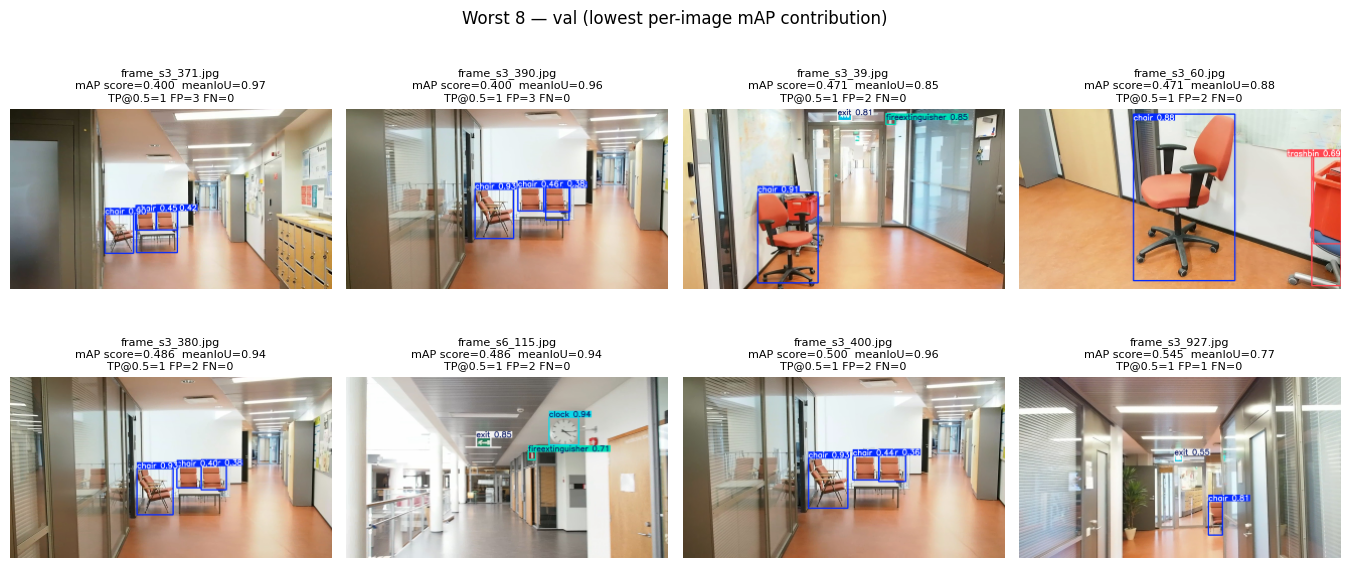

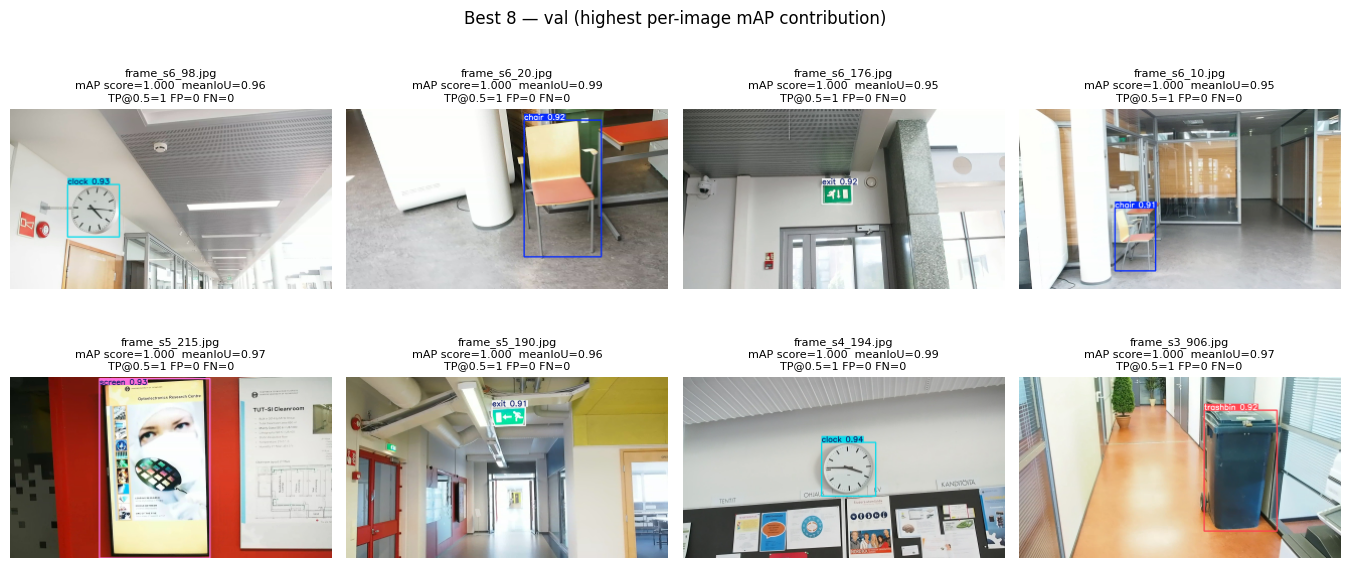

VizResult(work_dir=PosixPath('/home/francisco/workspace/personal_projects/docusketch_assignment/work_dirs/indoor_object_detection/original/best/experiment_2'), split='val', metrics={'mAP': 0.8353153726937137, 'AP50': 0.9856172684394205, 'AP75': 0.9595373615498939, 'precision': 0.9799845571289542, 'recall': 0.9650851755637356}, per_class={'chair': {'mAP': 0.8686583112047254, 'AP50': 0.9879968878447385, 'precision': 0.9759771993551523, 'recall': 0.8855421686746988}, 'clock': {'mAP': 0.8805715349562717, 'AP50': 0.995, 'precision': 0.9835829534167977, 'recall': 1.0}, 'exit': {'mAP': 0.8185720923982499, 'AP50': 0.9804536398467434, 'precision': 0.936777919111131, 'recall': 0.9629629629629629}, 'fireextinguisher': {'mAP': 0.8627835128823639, 'AP50': 0.9926094818192442, 'precision': 0.9749318566316548, 'recall': 0.9940476190476191}, 'printer': {'mAP': 0.8391952380952382, 'AP50': 0.995, 'precision': 1.0, 'recall': 1.0}, 'screen': {'mAP': 0.8287651515151515, 'AP50': 0.995, 'precision': 1.0, 'rec

In [11]:
%matplotlib inline

from visualize_predictions import run_visualization

run_visualization(
    training.work_dir,
    split="valid",
    device="0",
    display="notebook",
)